In [21]:

# 1. Load Cleaned Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")

# Use better plot style
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)


In [22]:

# 2. Basic Dataset Info
print("\n Dataset Shape:", df.shape)
print("\n Columns:\n", df.columns.tolist())
print("\n Dataset Info:")
print(df.info())
print("\n Summary Stats:")
print(df.describe(include="all").T)



 Dataset Shape: (44, 36)

 Columns:
 ['timestamp', 'name of the student', 'university roll no.', 'class roll no', 'year of study', 'age', 'course', 'department', 'have you taken a mooc course before?', 'which mooc platform did you use?', 'what was the domain of your course?', 'course duration', 'course start date', 'course end date', 'course difficulty level (self rated)', 'was the course self placed or instructor paced?', 'did your course contain more visual effects for better understanding of concepts?', 'average study time per week', 'how many lectures did you complete?', 'how many assignments did you complete?', 'did you participate in discussion forums?', 'did you take notes while learning?', 'how often did you revisit previous content?', 'did you take all the quiz and tests?', 'how many total exams you had to take in order to pass the course?', 'were the questions in exams similar to assignments and class or were they significantly different?', 'was your final exam conducted in 


 Missing Values:
timestamp                                                                                             0
name of the student                                                                                   0
university roll no.                                                                                   0
class roll no                                                                                         0
year of study                                                                                         0
age                                                                                                   0
course                                                                                                0
department                                                                                            0
have you taken a mooc course before?                                                                  0
which mooc platform did you use?              

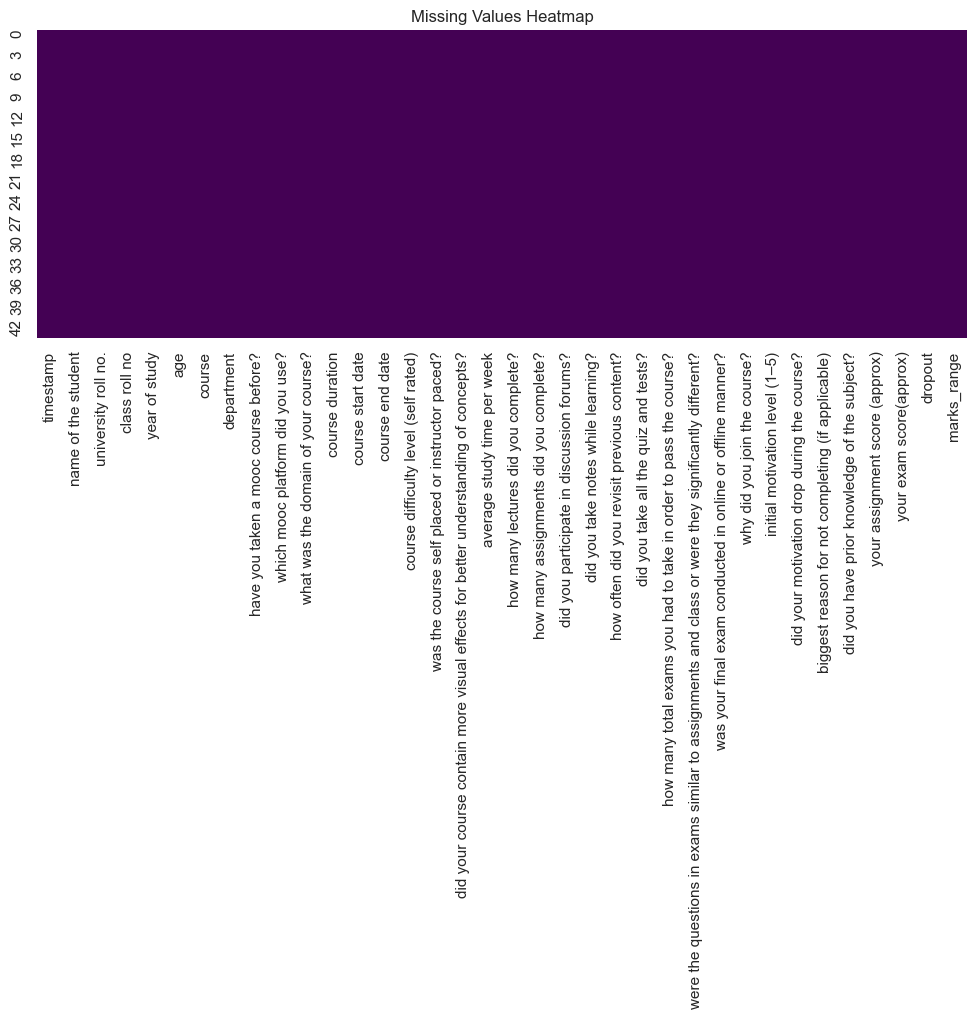

In [23]:

# 3. Missing Values Check
print("\n Missing Values:")
print(df.isnull().sum())

plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


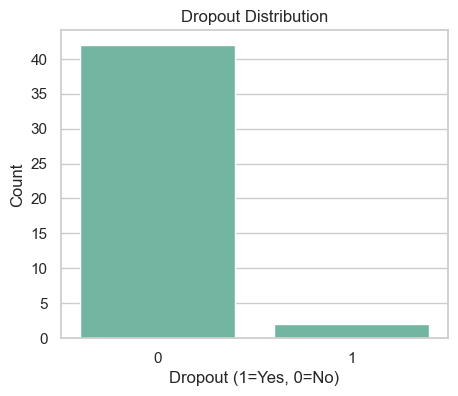


 Dropout Value Counts:
dropout
0    42
1     2
Name: count, dtype: int64


In [24]:

# 4. Target Variable Distribution (Dropout)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="dropout")
plt.title("Dropout Distribution")
plt.xlabel("Dropout (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

print("\n Dropout Value Counts:")
print(df["dropout"].value_counts())


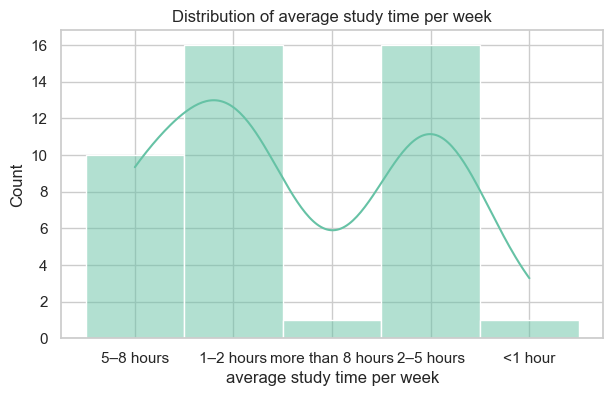

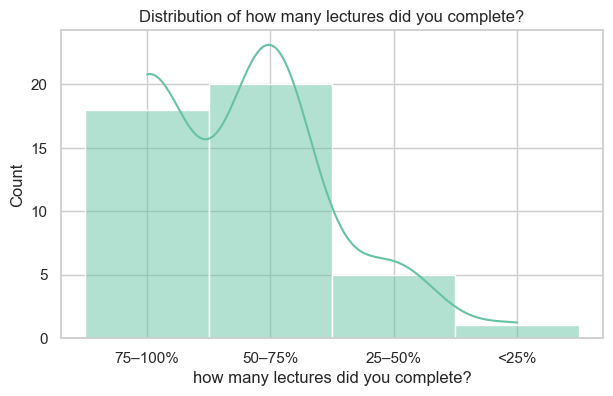

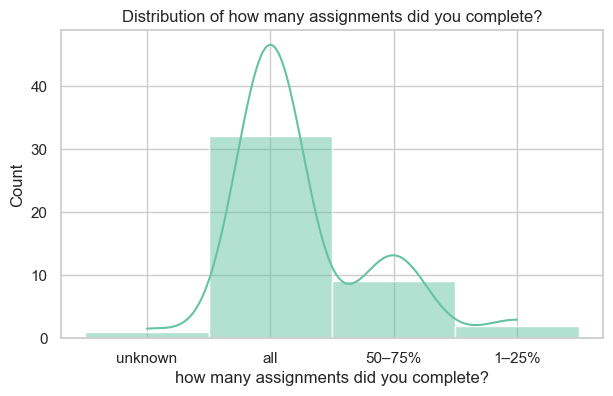

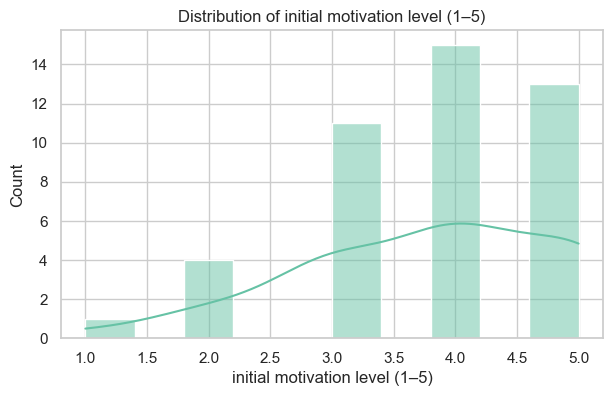

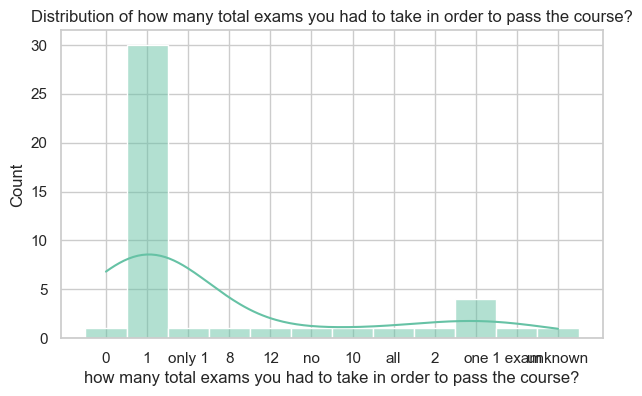

In [25]:


# 5. Numerical Feature Distributions (IMPORTANT ONLY)


num_cols = [
    "average study time per week",
    "how many lectures did you complete?",
    "how many assignments did you complete?",
    "initial motivation level (1–5)",
    "how many total exams you had to take in order to pass the course?"
]

for col in num_cols:
    if col in df.columns:
        plt.figure(figsize=(7,4))
        sns.histplot(df[col], bins=10, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()



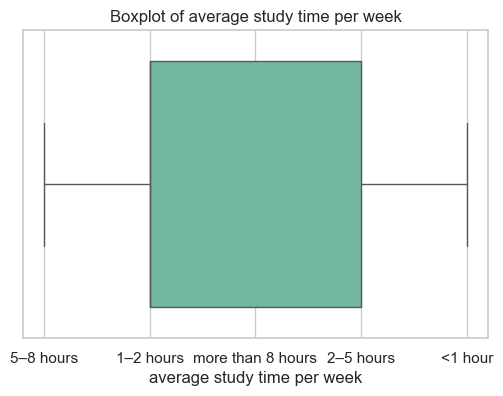

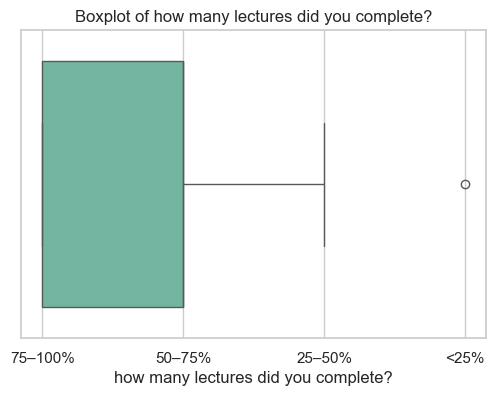

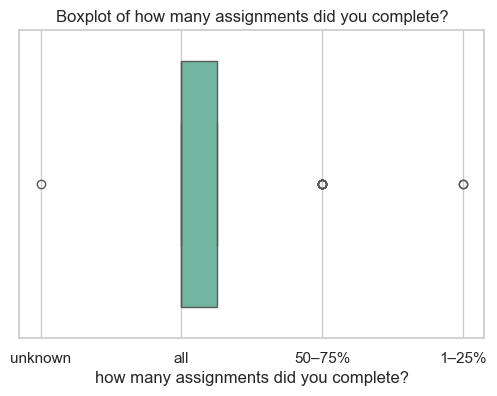

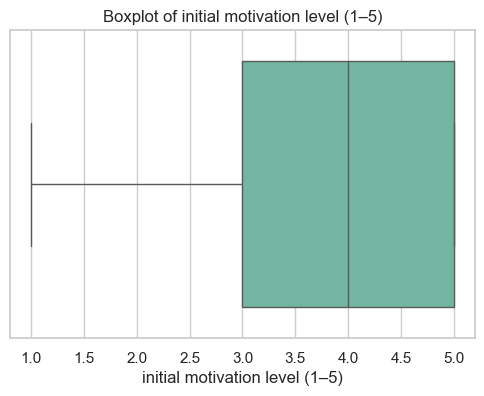

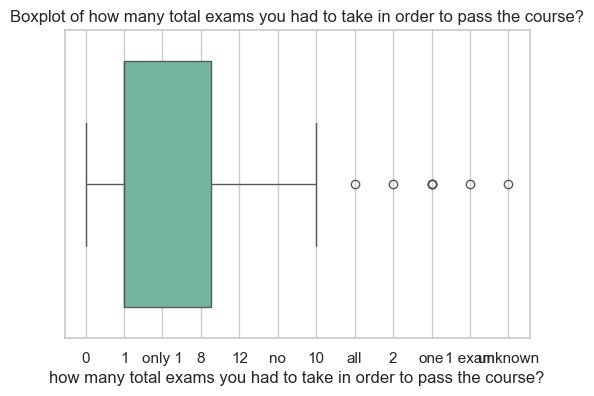

In [26]:

# 6. Boxplots - Outliers Check

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



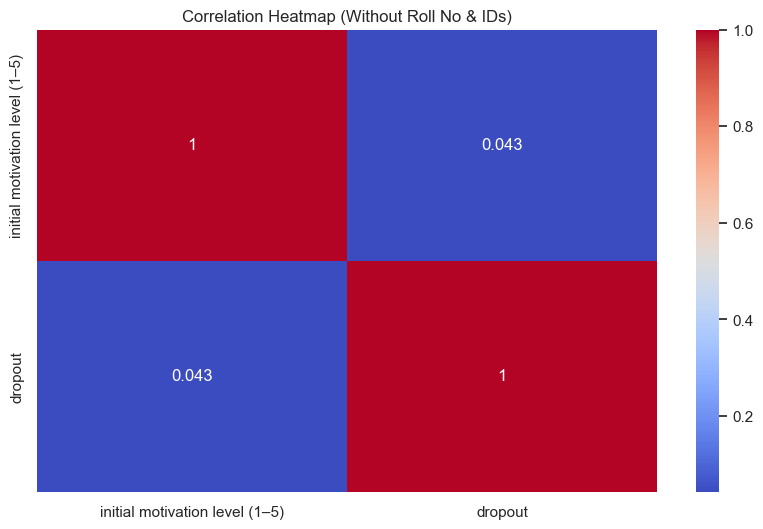

In [27]:

#  Correlation Heatmap (Error-Free)


# STEP 1: Lowercase and strip columns (for safety)
df.columns = df.columns.str.strip().str.lower()

# STEP 2: List of unwanted ID columns
id_cols = [
    "university roll no.",
    "name of the student",
    "class roll no",
    "timestamp"
]

# STEP 3: Remove ID columns only for heatmap calculation
df_corr = df.drop(columns=[col for col in id_cols if col in df.columns], errors='ignore')

# STEP 4: Select only numeric columns safely
numeric_cols = df_corr.select_dtypes(include=['number'])

# STEP 5: Create correlation matrix
corr = numeric_cols.corr()

# STEP 6: Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Without Roll No & IDs)")
plt.show()


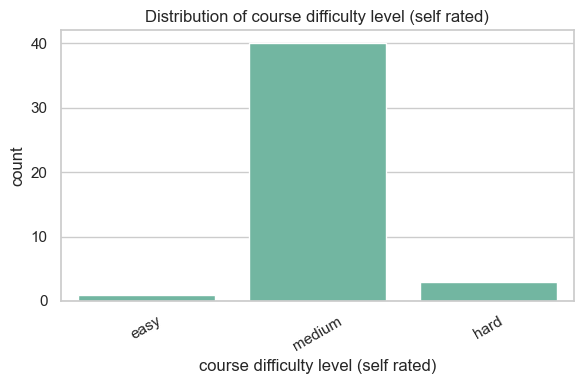

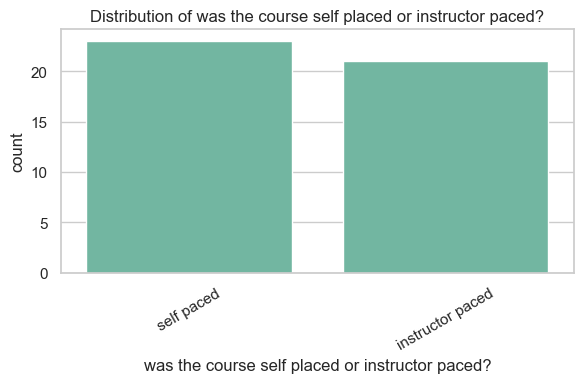

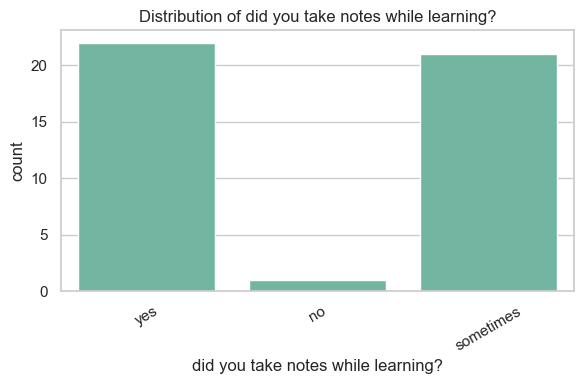

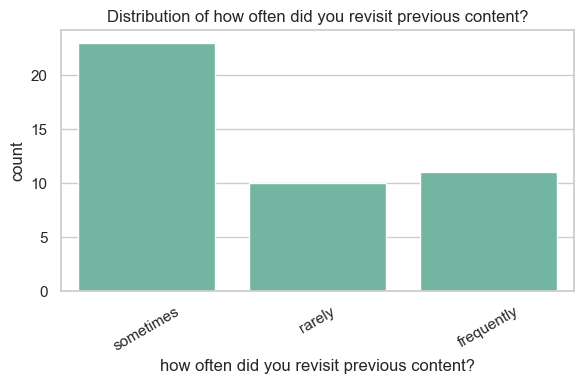

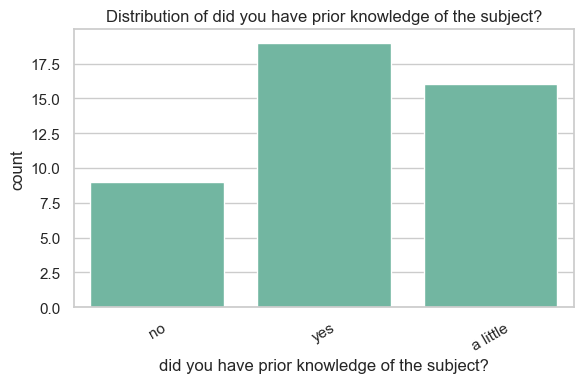

In [28]:


# 8. Categorical Feature Analysis (MINIMAL)


important_cat_cols = [
    "course difficulty level (self rated)",
    "was the course self placed or instructor paced?",
    "did you take notes while learning?",
    "how often did you revisit previous content?",
    "did you have prior knowledge of the subject?"
]

for col in important_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()



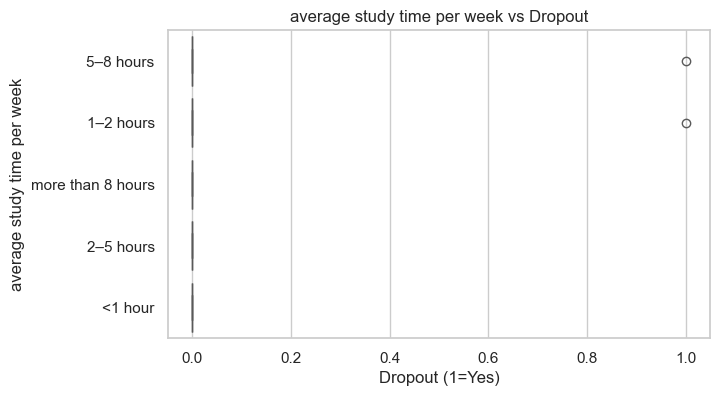

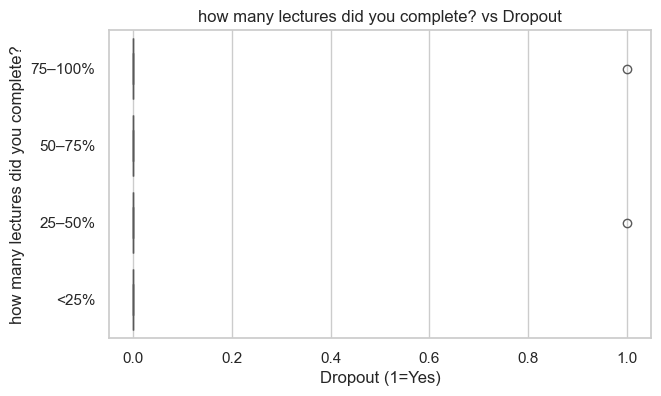

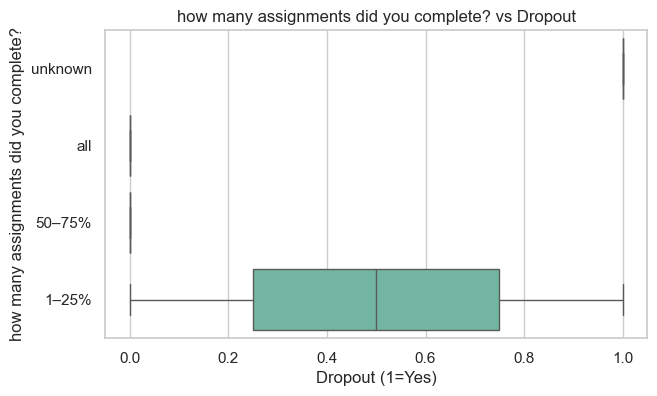

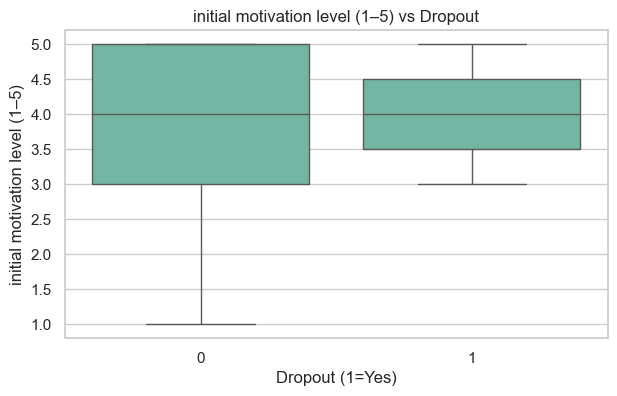

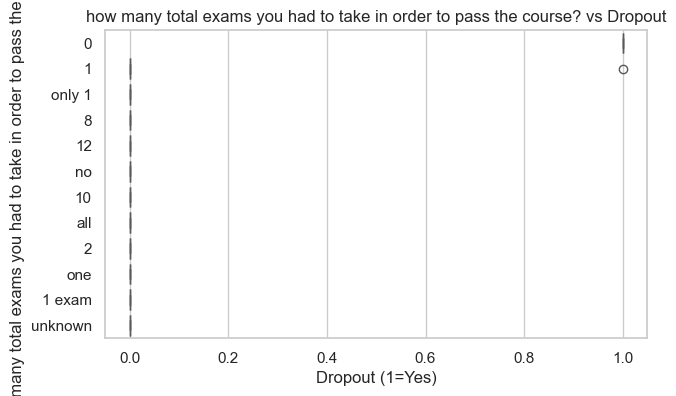

In [29]:
# Numeric vs Dropout
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df["dropout"], y=df[col])
    plt.title(f"{col} vs Dropout")
    plt.xlabel("Dropout (1=Yes)")
    plt.show()


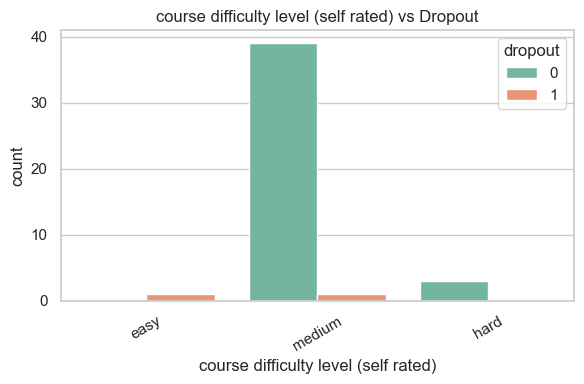

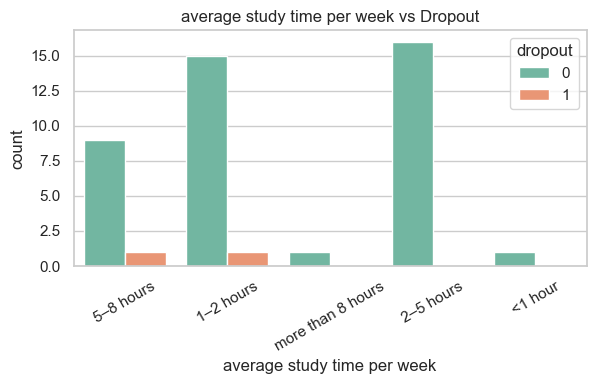

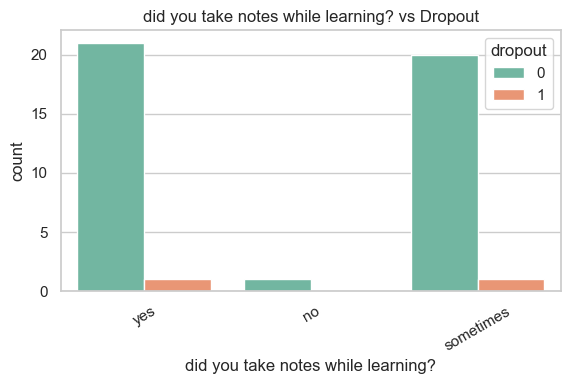

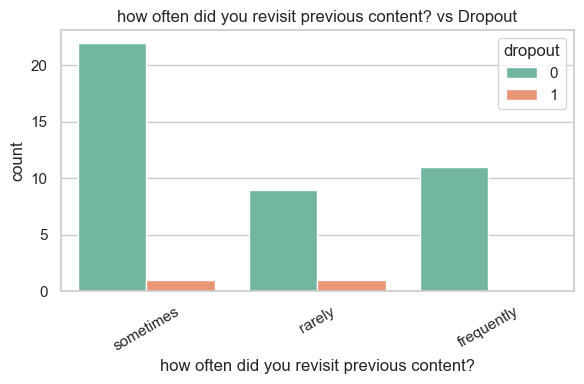

In [30]:


# 9. Relationship Between Key Categorical Features & Dropout


dropout_cat_cols = [
    "course difficulty level (self rated)",
    "average study time per week",
    "did you take notes while learning?",
    "how often did you revisit previous content?"
]

for col in dropout_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue="dropout")
        plt.title(f"{col} vs Dropout")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()



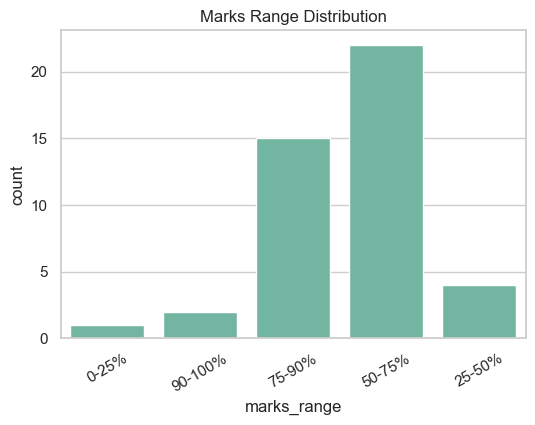

marks_range
50-75%     22
75-90%     15
25-50%      4
90-100%     2
0-25%       1
Name: count, dtype: int64


In [31]:
 #10. Marks Range Distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="marks_range")
plt.title("Marks Range Distribution")
plt.xticks(rotation=30)
plt.show()

print(df["marks_range"].value_counts())


In [32]:
print(df.columns.tolist())


['timestamp', 'name of the student', 'university roll no.', 'class roll no', 'year of study', 'age', 'course', 'department', 'have you taken a mooc course before?', 'which mooc platform did you use?', 'what was the domain of your course?', 'course duration', 'course start date', 'course end date', 'course difficulty level (self rated)', 'was the course self placed or instructor paced?', 'did your course contain more visual effects for better understanding of concepts?', 'average study time per week', 'how many lectures did you complete?', 'how many assignments did you complete?', 'did you participate in discussion forums?', 'did you take notes while learning?', 'how often did you revisit previous content?', 'did you take all the quiz and tests?', 'how many total exams you had to take in order to pass the course?', 'were the questions in exams similar to assignments and class or were they significantly different?', 'was your final exam conducted in online or offline manner?', 'why did y

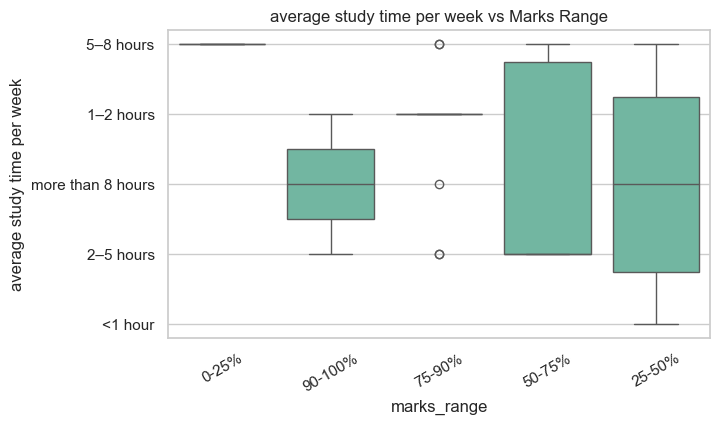

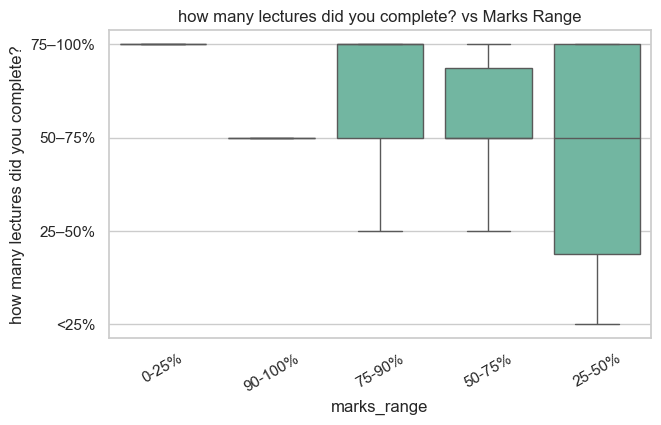

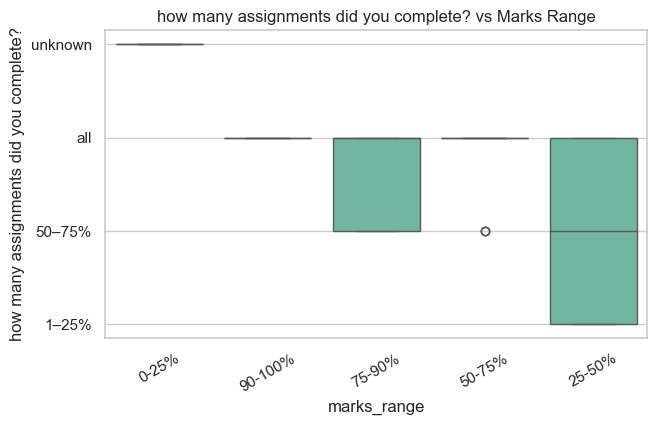

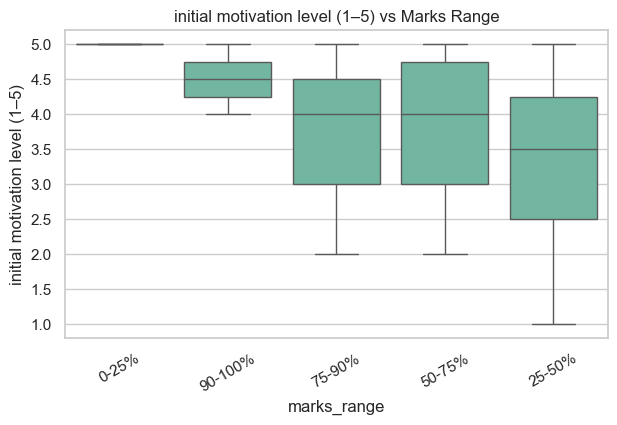

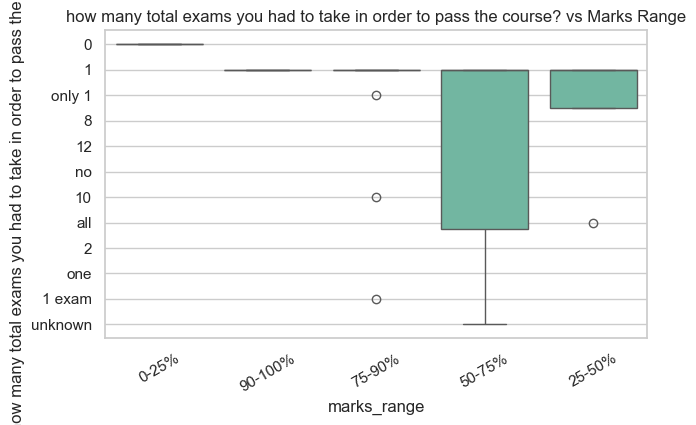

In [33]:


# 11. Numeric Features vs Marks Range

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df["marks_range"], y=df[col])
    plt.title(f"{col} vs Marks Range")
    plt.xticks(rotation=30)
    plt.show()


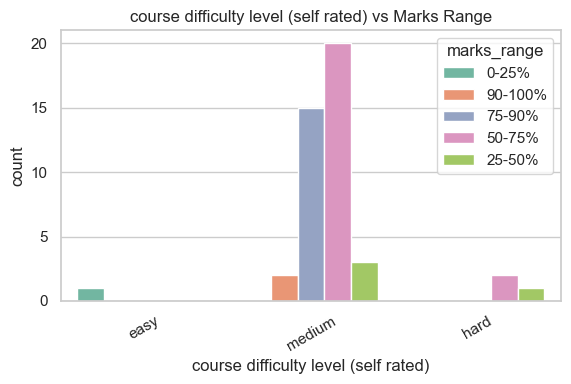

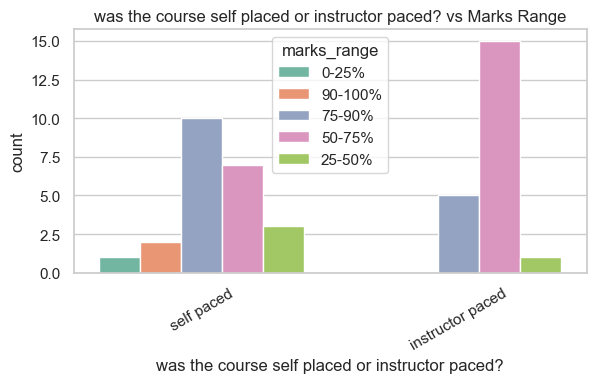

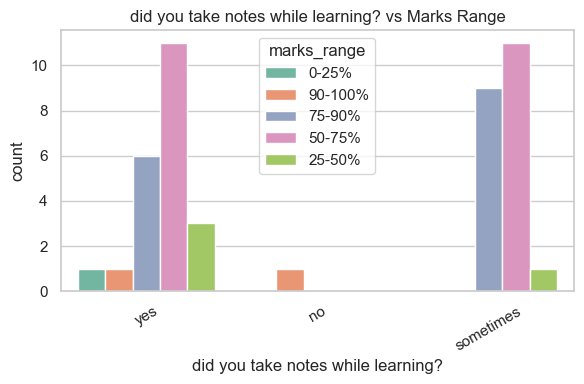

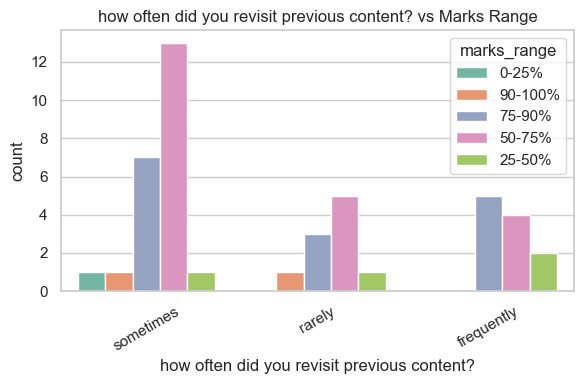

In [36]:


# 12. Key Categorical Features vs Marks Range (MINIMAL)

marks_cat_cols = [
    "course difficulty level (self rated)",
    "was the course self placed or instructor paced?",
    "did you take notes while learning?",
    "how often did you revisit previous content?"
]

for col in marks_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue="marks_range")
        plt.title(f"{col} vs Marks Range")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()



In [40]:

# TEMPORARY NUMERIC CONVERSION (EDA ONLY)


study_time_map = {
    "1–2 hours": 1.5,
    "2–5 hours": 3.5,
    "5–8 hours": 6.5,
    "more than 8 hours": 9
}

df["study_time_num"] = df["average study time per week"].map(study_time_map)


In [43]:
# Convert lecture completion to numeric (percentage midpoints)
lecture_map = {
    "1–25%": 12.5,
    "25–50%": 37.5,
    "50–75%": 62.5,
    "75–100%": 87.5,
    "all": 100
}

df["lectures_num"] = df["how many lectures did you complete?"].map(lecture_map)


# Convert assignment completion to numeric
assignment_map = {
    "1–25%": 12.5,
    "25–50%": 37.5,
    "50–75%": 62.5,
    "75–100%": 87.5,
    "all": 100
}

df["assignments_num"] = df["how many assignments did you complete?"].map(assignment_map)


In [44]:

# 13. Recommendation Support Analysis

recommend_cols = [
    "study_time_num",
    "lectures_num",
    "assignments_num"
]


print("\nAverage effort by Marks Range:")
print(
    df.groupby("marks_range")[recommend_cols]
      .mean()
      .round(2)
)





Average effort by Marks Range:
             study_time_num  lectures_num  assignments_num
marks_range                                               
0-25%                  6.50         87.50              NaN
25-50%                 3.83         70.83            56.25
50-75%                 3.95         65.91            94.89
75-90%                 2.93         75.83            85.00
90-100%                2.50         62.50           100.00
